# Project 4: Movie Review Classification with Naive Bayes

In this project, I build my own Naive Bayes classifier to predict whether a movie review is positive or negative.

The main steps are:
- process the review text into words
- remove stopwords
- count word frequencies in positive and negative reviews
- use Laplace smoothing
- classify reviews using log probabilities
- test the accuracy of the classifier
- analyze the results with word clouds and misclassified examples

In [72]:
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from wordcloud import WordCloud

In [73]:
# read the movie review dataset
movs = pd.read_csv("movie_reviews.csv")

# display the dataframe
movs

,review,sentiment
0,"This film is absolutely awful, but nevertheles...",negative
1,Well since seeing part's 1 through 3 I can hon...,negative
2,I got to see this film at a preview and was da...,positive
3,This adaptation positively butchers a classic ...,negative
4,Råzone is an awful movie! It is so simple. It ...,negative
...,...,...
24995,With this movie being the only Dirty Harry mov...,positive
24996,Any screen adaptation of a John Grisham story ...,positive
24997,This film captured my heart from the very begi...,positive
24998,A deplorable social condition triggers off the...,positive


In [74]:
# take one review from the dataframe
rev = movs.iloc[0]

# display the row
rev

review       This film is absolutely awful, but nevertheles...
sentiment                                             negative
Name: 0, dtype: object

In [75]:
# display only the text of the review
rev['review']

'This film is absolutely awful, but nevertheless, it can be hilarious at times, although this humor is entirely unintentional.<br /><br />The plot was beyond ridiculous. I don\'t even think a 2 year-old would be convinced by the ludicrous idiocy that the film-makers tried to slap together into a story. However, on the positive side, some of the horrifically inane plot twists provide a great deal of humor. For example, "Wow, Lady Hogbottom has a giant missile hidden in her back yard!" It gets worse (and even funnier), but I\'ll spare you.<br /><br />The acting is generally laughable. Most of the kids\' roles are sort of cute, but not very believable. On the other hand, Annie is pretty awful all-around. The adults don\'t take their roles seriously at all, but this is largely a good thing. If they\'d tried to be believable, the film would\'ve been even worse. Which is difficult to imagine.<br /><br />Once you get past the overall crappiness of the movie, there are actually a few standout 

## Word Processing

Before building the classifier, I first need to turn each review into a list of words.

I will: 1.convert all letters to lowercase   
2.keep apostrophes in words like "don't"    
3.remove common stopwords

Function to turn review into words

In [76]:
def RevToList(RevStr):
    # convert the text to lowercase so words like "Good" and "good" are treated the same
    lowcasestr = RevStr.lower()
    
    # extract words
    words = re.findall(r"[\w']+", lowcasestr)
    
    return words

Test the function

In [77]:
WeirdCase = "This STRing has UPPERCASE LeTTeRs. You won't do that"

print(WeirdCase.lower())
print(re.findall(r"[\w']+", WeirdCase))
print(RevToList(rev['review'])[:30])

this string has uppercase letters. you won't do that
['This', 'STRing', 'has', 'UPPERCASE', 'LeTTeRs', 'You', "won't", 'do', 'that']
['this', 'film', 'is', 'absolutely', 'awful', 'but', 'nevertheless', 'it', 'can', 'be', 'hilarious', 'at', 'times', 'although', 'this', 'humor', 'is', 'entirely', 'unintentional', 'br', 'br', 'the', 'plot', 'was', 'beyond', 'ridiculous', 'i', "don't", 'even', 'think']


Load stopwords

In [78]:
# open the stopwords file
File = open('stopwords.txt')

# read the entire file as one string
stopwordstr = File.read()

# close the file
File.close()

# split the string into a list using comma
stopwordlist = stopwordstr.split(',')

# convert to a set for faster lookup later
stopwords = set(stopwordlist)

# check results
print("Number of stopwords:", len(stopwords))
print(list(stopwords)[:20])

Number of stopwords: 119
['like', 'cannot', 'must', 'how', 'across', 'some', 'be', 'and', 'by', 'any', 'with', 'also', 'us', 'most', 'will', 'every', 'have', 'likely', 'me', 'says']


Remove stopwords

In [79]:
def RevToListNoStop(RevStr):
    # convert the review to lowercase
    lowcasestr = RevStr.lower()
    
    # use regex to extract words (including words with apostrophes)
    words = re.findall(r"[\w']+", lowcasestr)
    
    # create a new list to store filtered words
    filtered_words = []
    
    # go through each word and remove stopwords
    for w in words:
        if w not in stopwords:
            filtered_words.append(w)
    
    return filtered_words

Test the cleaned word list

In [80]:
print(RevToList(rev['review'])[:30])
print(RevToListNoStop(rev['review'])[:30])

['this', 'film', 'is', 'absolutely', 'awful', 'but', 'nevertheless', 'it', 'can', 'be', 'hilarious', 'at', 'times', 'although', 'this', 'humor', 'is', 'entirely', 'unintentional', 'br', 'br', 'the', 'plot', 'was', 'beyond', 'ridiculous', 'i', "don't", 'even', 'think']
['film', 'absolutely', 'awful', 'nevertheless', 'hilarious', 'times', 'although', 'humor', 'entirely', 'unintentional', 'br', 'br', 'plot', 'beyond', 'ridiculous', "don't", 'even', 'think', '2', 'year', 'old', 'convinced', 'ludicrous', 'idiocy', 'film', 'makers', 'tried', 'slap', 'together', 'story']


## Split the Data

I split the reviews into a training set and a testing set.
The training set is used to build the classifier, and the testing set is used to measure accuracy.

Train and test data split

In [81]:
# split the dataset into training and testing sets
# 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    movs['review'],
    movs['sentiment'],
    test_size=0.2,
    random_state=42
)

print("Training size:", len(X_train))
print("Testing size:", len(X_test))

Training size: 20000
Testing size: 5000


Separate positive and negative training reviews

In [82]:
# separate the training reviews by sentiment
pos_train = X_train[y_train == 'positive']
neg_train = X_train[y_train == 'negative']

print("Positive training reviews:", len(pos_train))
print("Negative training reviews:", len(neg_train))

Positive training reviews: 10029
Negative training reviews: 9971


## Count Word Frequencies

Next, I count how many times each word appears in positive and negative training reviews.

Count negative words

In [83]:
NegWordCounts = {}

# go through each negative review
for rev in neg_train:
    rewords = RevToListNoStop(rev)
    
    # count each word
    for w in rewords:
        if w in NegWordCounts:
            NegWordCounts[w] += 1
        else:
            NegWordCounts[w] = 1

Negative dataframe

In [84]:
# put the negative word counts into a dataframe
negdf = pd.DataFrame({'Negative': NegWordCounts})

# sort from highest count to lowest count
negdf.sort_values(by='Negative', ascending=False, inplace=True)

negdf

,Negative
br,42098
movie,19576
film,14841
one,10394
out,7124
...,...
ghungroo,1
gravitation,1
agha,1
jalal,1


Count positive words

In [85]:
PosWordCounts = {}

# go through each positive review
for rev in pos_train:
    rewords = RevToListNoStop(rev)
    
    # count each word
    for w in rewords:
        if w in PosWordCounts:
            PosWordCounts[w] += 1
        else:
            PosWordCounts[w] = 1

Positive dataframe

In [86]:
# put the positive word counts into a dataframe
posdf = pd.DataFrame({'Positive': PosWordCounts})

# sort from highest count to lowest count
posdf.sort_values(by='Positive', ascending=False, inplace=True)

posdf

,Positive
br,39493
film,16617
movie,15275
one,10903
it's,6879
...,...
assessing,1
commuter,1
'see',1
'harry',1


## Word Clouds

Now I visualize the most common words in positive and negative reviews.

Negative word cloud

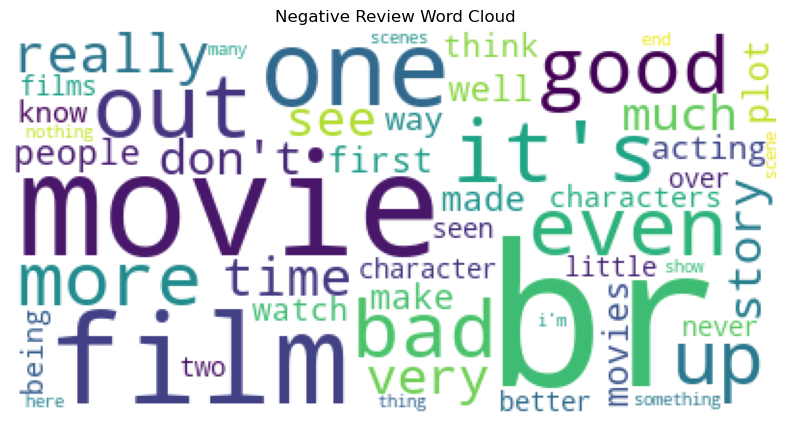

In [87]:
wc = WordCloud(max_words=50, background_color='white')

wc.generate_from_frequencies(negdf['Negative'])

plt.figure(figsize=(10, 5))
plt.imshow(wc)
plt.axis('off')
plt.title("Negative Review Word Cloud")
plt.show()

Positive word cloud

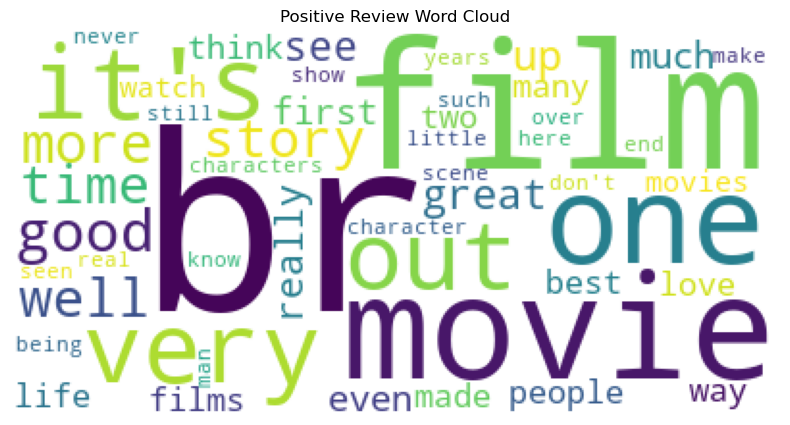

In [88]:
wc = WordCloud(max_words=50, background_color='white')

wc.generate_from_frequencies(posdf['Positive'])

plt.figure(figsize=(10, 5))
plt.imshow(wc)
plt.axis('off')
plt.title("Positive Review Word Cloud")
plt.show()

## Word Cloud Analysis

The negative word cloud contains words such as bad, worst, boring, and waste.

The positive word cloud contains words such as great, love,  best, and well.

Both word clouds contain common movie-related words, but the emotional words are different.  
This shows that positive and negative reviews often use different descriptive language.

## Naive Bayes Classifier

Now I build my own Naive Bayes classifier.

Bayes' theorem is:

\[
P(A|B)=\frac{P(B|A)P(A)}{P(B)}
\]

For this project:
- \(A\) is the sentiment class (positive or negative)
- \(B\) is the list of words in the review

Using the Naive Bayes assumption, I treat the words as independent and multiply their probabilities.  
To avoid numerical underflow, I use log probabilities instead of multiplying many small numbers directly.

Vocabulary and Laplace smoothing

In [99]:
# create the full vocabulary from both classes
vocab = set(PosWordCounts.keys()) | set(NegWordCounts.keys())

# apply Laplace smoothing by adding 1 to each word count
for w in vocab:
    
    # if the word already exists in positive counts, add 1
    if w in PosWordCounts:
        PosWordCounts[w] += 1
    else:
        # if not, initialize it as 1
        PosWordCounts[w] = 1
    
    # do the same for negative counts
    if w in NegWordCounts:
        NegWordCounts[w] += 1
    else:
        NegWordCounts[w] = 1

totals and priors

In [90]:
# total number of words in each class after smoothing
TotalPosWords = sum(PosWordCounts.values())
TotalNegWords = sum(NegWordCounts.values())

# prior probabilities for positive and negative reviews
PPos = len(pos_train) / len(X_train)
PNeg = len(neg_train) / len(X_train)

print("Total positive words:", TotalPosWords)
print("Total negative words:", TotalNegWords)
print("P(positive):", PPos)
print("P(negative):", PNeg)

Total positive words: 1406326
Total negative words: 1349461
P(positive): 0.50145
P(negative): 0.49855


Classifier function

In [91]:
def ClassifyReview(RevStr):
    # convert the review to a cleaned list of words
    words = RevToListNoStop(RevStr)
    
    # start with the log prior probabilities
    log_pos = math.log(PPos)
    log_neg = math.log(PNeg)
    
    # add the log probability of each word
    for w in words:
        if w in vocab:
            log_pos += math.log(PosWordCounts[w] / TotalPosWords)
            log_neg += math.log(NegWordCounts[w] / TotalNegWords)
    
    # choose the class with the larger log probability
    if log_pos > log_neg:
        return 'positive'
    else:
        return 'negative'

Test classifier on one review

In [92]:
sample_review = X_test.iloc[0]
true_label = y_test.iloc[0]
pred_label = ClassifyReview(sample_review)

print("True label:", true_label)
print("Predicted label:", pred_label)
print(sample_review[:500])

True label: negative
Predicted label: negative
Immediately after renting and watching this movie several years ago, a friend and I decided that it defined the absolute zero on the movie scale. There was nothing about the movie that could have been done worse than it was. To this day we still rate movies, even very bad ones, by how much better than "The Lonely Lady" they are.<br /><br />A long time ago I saw an interview with Eleanor Perry, who wrote the screenplays for, among other things, "Last Summer" and "Diary of a Mad Housewife," and sh


Accuracy function

In [93]:
def ReviewAccuracy(XData, YData):
    correct = 0
    
    # go through each review in the dataset
    for rev, label in zip(XData, YData):
        pred = ClassifyReview(rev)
        
        if pred == label:
            correct += 1
    
    # return the fraction classified correctly
    return correct / len(XData)

Test accuracy

In [94]:
acc = ReviewAccuracy(X_test, y_test)
print("Test accuracy:", acc)

Test accuracy: 0.8678


## Misclassified Reviews

To better understand the classifier, I look at some reviews that were classified incorrectly.

Find misclassified examples

In [95]:
misclassified = []

for rev, label in zip(X_test, y_test):
    pred = ClassifyReview(rev)
    
    if pred != label:
        misclassified.append((rev, label, pred))

In [96]:
print("Number of misclassified reviews:", len(misclassified))

Number of misclassified reviews: 661


Show a few mistakes

In [97]:
for i in range(3):
    print("Example", i+1)
    print("True label:", misclassified[i][1])
    print("Predicted label:", misclassified[i][2])
    print(misclassified[i][0][:700])
    print("-" * 80)

Example 1
True label: positive
Predicted label: negative
This was a highly original decent movie, and a brave move for all those involved. I don't care if it's not the most well put-together movie of all time, the fact that it has Eddie Murphy doing something non-formulaic, and that I don't know what will happen next, makes it a favorite of mine. I wish more movies were as imaginative as this one, rather than the same old formula for entertainment.
--------------------------------------------------------------------------------
Example 2
True label: positive
Predicted label: negative
The plot is real horrific, the atmosphere really depressive, unusual for a low-budget production like that, and at least, for a German production. A little bit of Indian spirituality, mystic thriller and slasher movie mixed together. The development of plot and characters are great, the sets very close to reality, without any studio-atmosphere. It could be perfect, but at unfortunately some things were a l

## Misclassification Analysis

Some reviews are misclassified because:
- they contain mixed positive and negative language
- they use sarcasm or irony
- they use unusual wording
- they contain phrases like "not good", where word-by-word counting can be misleading

This is one weakness of Naive Bayes, because it does not understand meaning the way a human does.

## Custom Test Reviews

I can also test the classifier on my own short review examples.

Test our own reviews

In [98]:
my_reviews = [
    "This movie was amazing and I loved every minute of it.",
    "This was boring, slow, and a complete waste of time.",
    "The acting was good but the story was weak.",
    "I did not enjoy this movie at all.",
    "This film was not bad and had some funny moments."
]

for r in my_reviews:
    print("Review:", r)
    print("Prediction:", ClassifyReview(r))
    print()

Review: This movie was amazing and I loved every minute of it.
Prediction: positive

Review: This was boring, slow, and a complete waste of time.
Prediction: negative

Review: The acting was good but the story was weak.
Prediction: negative

Review: I did not enjoy this movie at all.
Prediction: positive

Review: This film was not bad and had some funny moments.
Prediction: negative



## Custom Review Analysis

The classifier works well on clearly positive and clearly negative reviews.

However, it may struggle with reviews that contain negation, such as "not bad" or "not good", because it treats words independently instead of fully understanding the phrase.

## Conclusion

In this project, I implemented my own Naive Bayes classifier for movie review sentiment classification. I first processed the review text into word lists, removed stopwords, and counted the word frequencies in positive and negative reviews. Then I used Laplace smoothing and log probabilities to classify new reviews.

The classifier achieved good accuracy on the testing set and showed clear differences between positive and negative review language in the word clouds. However, the model also has some weaknesses. It can struggle with negation and reviews with mixed sentiment.

Overall, this project shows that Naive Bayes is a simple but useful method for text classification.